<a href="https://colab.research.google.com/github/Queenimoh/Queen-7150CEM/blob/main/Queen_Imoh_7150CEM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# --------------- Queen Imoh - 7150CEM ---------------
print("Queen Imoh - 7150CEM")

Queen Imoh - 7150CEM


In [5]:
# Install required packages
!pip -q install openpyxl seaborn wordcloud

In [6]:
# Import required libraries
import os, random, warnings, json
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Bidirectional, LSTM
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

In [7]:
# To ensure reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [9]:
# Load the dataset
from google.colab import files

print("DDI_data.csv")
uploaded = files.upload()

df = pd.read_csv("DDI_data.csv")
df.head()

DDI_data.csv


Saving DDI_data.csv to DDI_data.csv


,drug1_id,drug2_id,drug1_name,drug2_name,interaction_type
0,DB00006,DB00346,Bivalirudin,Alfuzosin,serum concentration
1,DB00006,DB13783,Bivalirudin,Acemetacin,risk or severity of bleeding
2,DB00006,DB06605,Bivalirudin,Apixaban,anticoagulant activities
3,DB00006,DB06695,Bivalirudin,Dabigatran etexilate,anticoagulant activities
4,DB00006,DB09075,Bivalirudin,Edoxaban,anticoagulant activities


In [10]:
# This shows the total number of rows and columns in the original dataset from DrugBank
print("Data shape:", df.shape)

Data shape: (222696, 5)


In [13]:
# Handling Class Imbalance
# Restrict to top 20 interaction types (by frequency) to reduce the effect of class imbalance because
# some interaction types appeared more frequently while some appeared just very few times
# This ensures that each class has sufficient training samples and allows the models to learn meaningful patterns.
# By restricting to the top 20 interactions we now have 207407 rows of data

TOP_N = 20
label_counts = df['interaction_type'].value_counts()
top_labels = label_counts.head(TOP_N).index.tolist()
df = df[df['interaction_type'].isin(top_labels)].copy()
df = df.drop_duplicates(subset=['text', 'interaction_type']).reset_index(drop=True)
print('After top 20 filter:', len(df))
print(df['interaction_type'].value_counts().head(20))

After top 20 filter: 207407
interaction_type
risk or severity of adverse effects                              62767
metabolism                                                       42811
serum concentration                                              39244
therapeutic efficacy                                             12807
hypotensive activities                                           10051
QTc-prolonging activities                                         5837
antihypertensive activities                                       5638
central nervous system depressant (CNS depressant) activities     5279
anticoagulant activities                                          4344
vasoconstricting activities                                       2577
hypoglycemic activities                                           2461
risk or severity of hypotension                                   1840
sedative activities                                               1740
hypokalemic activities          

In [14]:
# Create new columns to show drugs that interact with each other and their interaction type for better semantics
# and help easy readability of the drug interactions
df = df.dropna(subset=['drug1_name', 'drug2_name', 'interaction_type']).copy()
df['text'] = df['drug1_name'].astype(str).str.strip() + ' + ' + df['drug2_name'].astype(str).str.strip()
df['sentence'] = df['drug1_name'].astype(str).str.strip() + ' + ' + df['drug2_name'].astype(str).str.strip() + ' causes ' + df['interaction_type'].astype(str).str.strip()
print(df.shape)

(207407, 7)


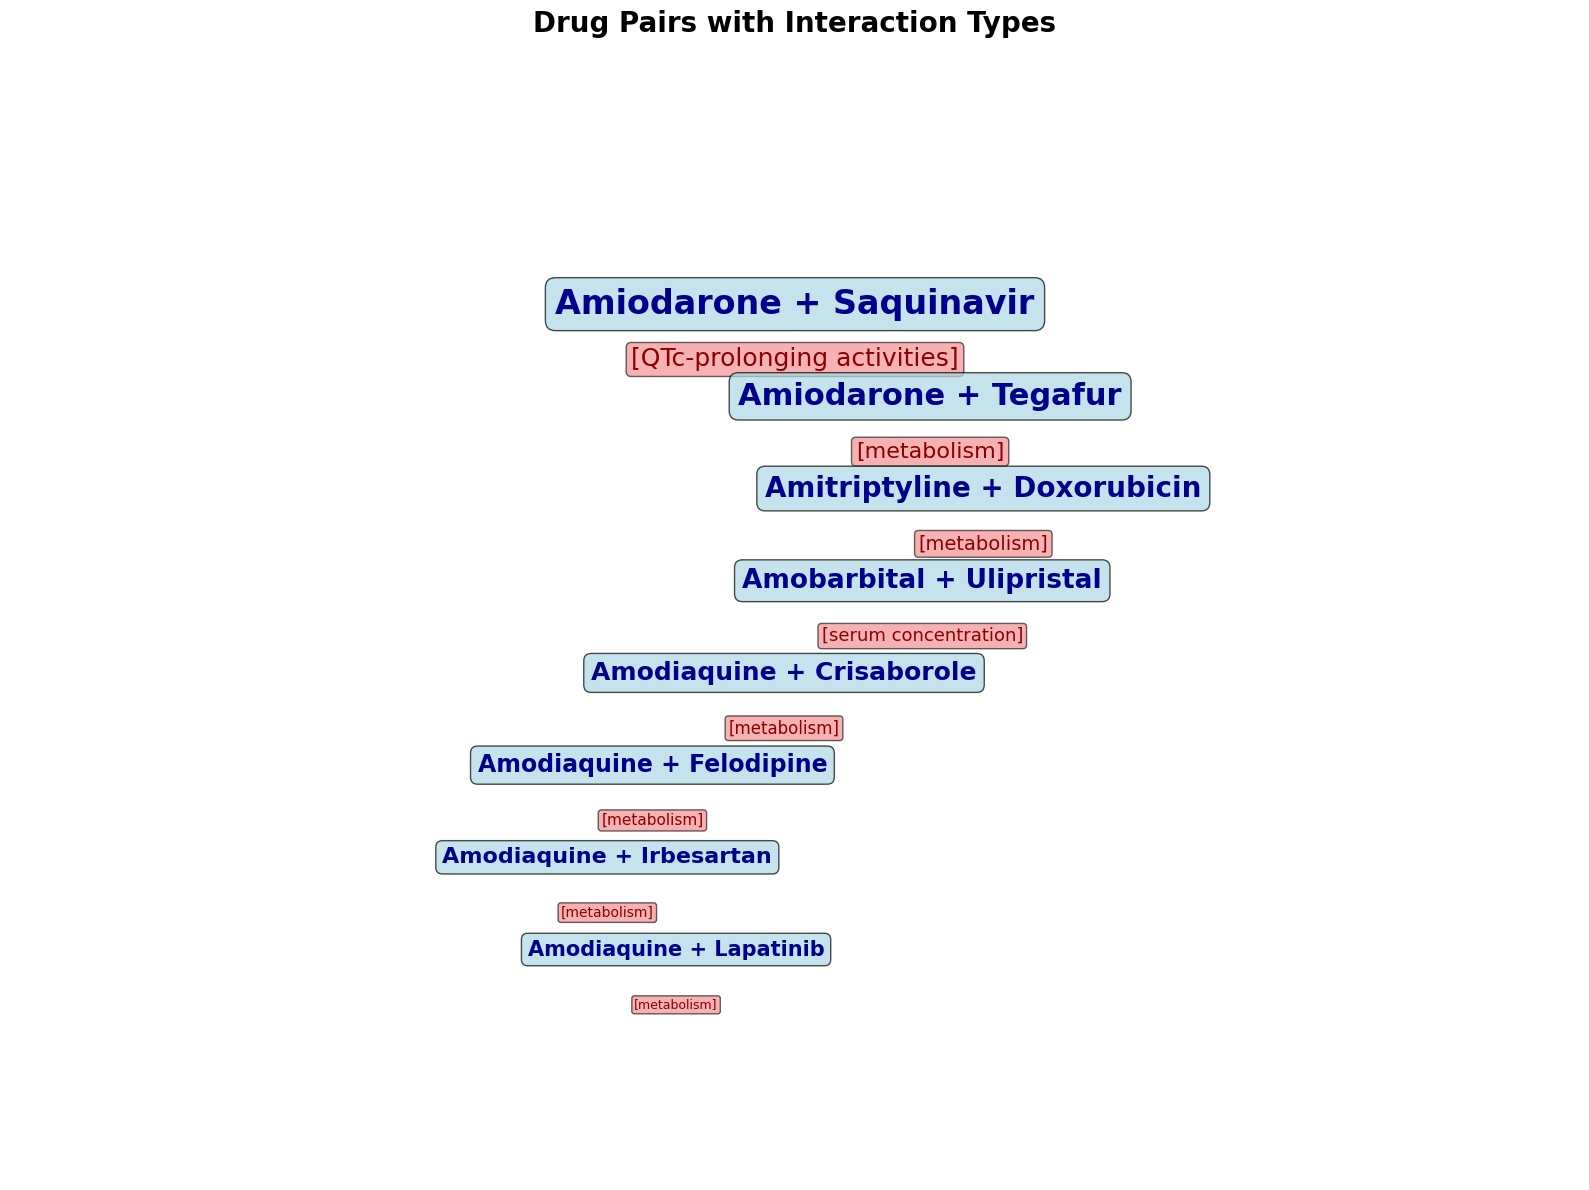

In [15]:
# Top 20 most frequent drug pairs from top 20 interaction types
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.text import TextPath
from matplotlib.patches import PathPatch
import numpy as np


df_top20 = df[df['interaction_type'].isin(df['interaction_type'].value_counts().head(20).index)]
top_pairs = df_top20.groupby(['drug1_name', 'drug2_name']).size().nlargest(8).index

# Create drug pairs with their dominant interaction to show a similar representaion of what the models using for the detection are suppose
# to show once they spot an interaction between two drugs
drug_interactions = []
for (drug1, drug2) in top_pairs:
    common_interaction = df_top20[
        (df_top20['drug1_name']==drug1) &
        (df_top20['drug2_name']==drug2)
    ]['interaction_type'].mode().iloc[0]
    drug_interactions.append((f"{drug1} + {drug2}", f"[{common_interaction}]"))

# Visualise
fig, ax = plt.subplots(1, 1, figsize=(16, 12))
ax.set_xlim(0, 10)
ax.set_ylim(0, 12)
ax.axis('off')

# Position each drug pair with its interaction type directly under it in a square bracket for easy readability
y_positions = [9.5, 8.5, 7.5, 6.5, 5.5, 4.5, 3.5, 2.5]
sizes = [24, 22, 20, 19, 18, 17, 16, 15]

for i, ((drug_pair, bracket), y_pos, size) in enumerate(zip(drug_interactions, y_positions, sizes)):
    x_pos = 5 + np.sin(i*0.8)*1.2

    ax.text(x_pos, y_pos, drug_pair, fontsize=size, fontweight='bold',
            ha='center', va='center', color='darkblue',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.7))


    ax.text(x_pos, y_pos-0.6, bracket, fontsize=size-6, fontweight='normal',
            ha='center', va='center', color='darkred',
            bbox=dict(boxstyle="round,pad=0.2", facecolor='lightcoral', alpha=0.6))

plt.title('Drug Pairs with Interaction Types',
          fontsize=20, fontweight='bold', pad=30)
plt.tight_layout()
plt.savefig('drug_pairs_with_brackets_exact.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()


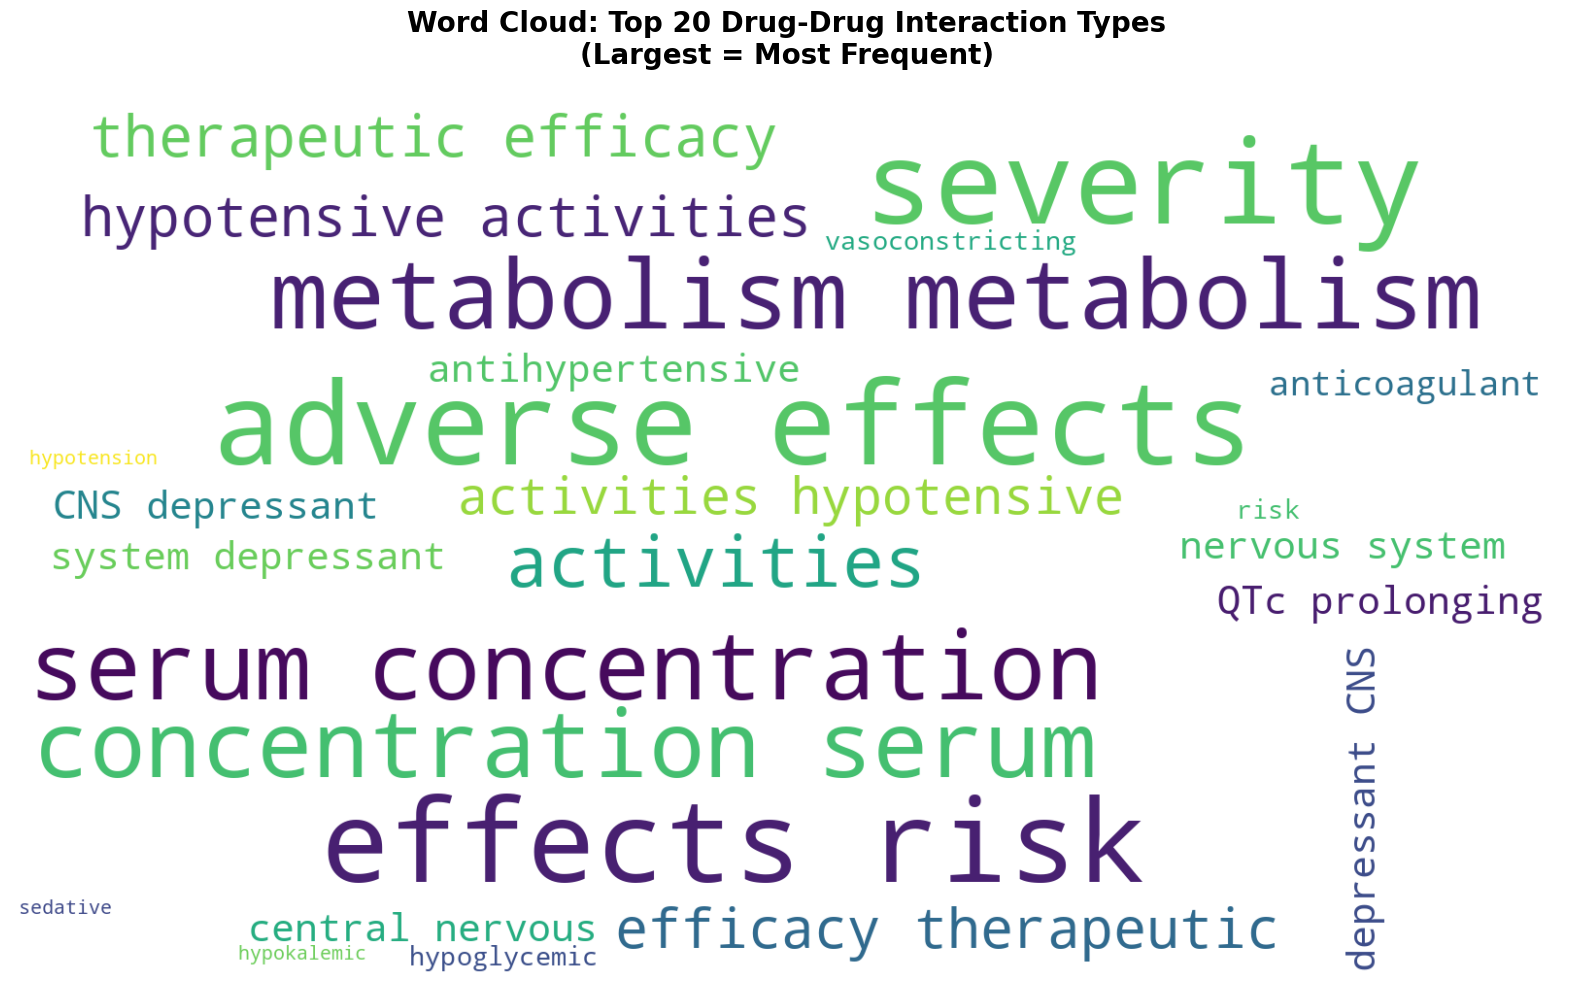

In [16]:
# Wordcloud showing the top 20 interactions types for the drug pairs
from wordcloud import WordCloud
import matplotlib.pyplot as plt

label_counts = df['interaction_type'].value_counts().head(20)

# Create weighted text (frequency = size)
wc_text = ''
for interaction, count in label_counts.items():
    wc_text += f" {interaction}" * int(count / 1000)

# Wordcloud formatting to ensure easy readability
wc = WordCloud(
    width=1600, height=900,
    background_color='white',
    colormap='viridis',
    max_words=25,
    min_font_size=14,
    max_font_size=120,
    relative_scaling=0.5,
    prefer_horizontal=0.95,
    margin=10,
    random_state=42
).generate(wc_text)

plt.figure(figsize=(18, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud: Top 20 Drug-Drug Interaction Types\n(Largest = Most Frequent)',
          fontsize=20, fontweight='bold', pad=30)
plt.tight_layout()
plt.savefig('top20_interactions_wordcloud.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [17]:
# Encode labels because most machine learning models cannot work directly with categorical labels as strings.
# They require numeric input

le = LabelEncoder()
df['y'] = le.fit_transform(df['interaction_type'].astype(str))
X = df['text'].values
y = df['y'].values
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)
print('Splits:', len(X_train), len(X_val), len(X_test))

Splits: 145184 31111 31112


In [18]:
# Create TF-IDF features for machine learning models to evaluate the importance of different words in a sentence
vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=50000, min_df=2)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)
print('TF-IDF shape:', X_train_tfidf.shape)

TF-IDF shape: (145184, 4150)


In [19]:
# Train Machine Learning Models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, classification_report
)

models_full = {
    'Logistic Regression': LogisticRegression(max_iter=500, class_weight='balanced'),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)
}

results = []
trained_models = {}

for name, model in models_full.items():
    print(f'Training {name}...')
    model.fit(X_train_tfidf, y_train)
    trained_models[name] = model
    pred = model.predict(X_test_tfidf)

   # Evaluate machine learning models using key metrics
    acc = accuracy_score(y_test, pred)
    prec_w = precision_score(y_test, pred, average='weighted', zero_division=0)
    rec_w = recall_score(y_test, pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test, pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_test, pred, average='macro', zero_division=0)

    print(f'{name}: F1_weighted={f1_w:.4f}, Accuracy={acc:.4f}')
    results.append([name, acc, prec_w, rec_w, f1_w, f1_m])

# Train support vector machine on 10000 samples to enable rapid SVM hyperparameter optimization
# and cross-validation while preserving class distribution via stratified sampling of top 20 interaction types.
sample_size = min(10000, len(X_train))
train_idx = np.random.choice(len(X_train), sample_size, replace=False)
X_train_svm = X_train_tfidf[train_idx]
y_train_svm = y_train[train_idx]

svm_model = SVC(kernel='linear', probability=True, class_weight='balanced', random_state=42, max_iter=1000)
svm_model.fit(X_train_svm, y_train_svm)
trained_models['SVM'] = svm_model
pred_svm = svm_model.predict(X_test_tfidf)

# Evaluate SVM using key metrics
acc_svm = accuracy_score(y_test, pred_svm)
prec_w_svm = precision_score(y_test, pred_svm, average='weighted', zero_division=0)
rec_w_svm = recall_score(y_test, pred_svm, average='weighted', zero_division=0)
f1_w_svm = f1_score(y_test, pred_svm, average='weighted', zero_division=0)
f1_m_svm = f1_score(y_test, pred_svm, average='macro', zero_division=0)

print(f'SVM: F1_weighted={f1_w_svm:.4f}, Accuracy={acc_svm:.4f}')
results.append(['SVM', acc_svm, prec_w_svm, rec_w_svm, f1_w_svm, f1_m_svm])

# Perfomance of Machine Learning Models
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision_W', 'Recall_W', 'F1_Weighted', 'F1_Macro'])
print('\n' + '='*80)
print('Perfomance of Machine Learning Models')
print('='*80)
print(results_df.round(4).sort_values('F1_Weighted', ascending=False).to_string(index=False))

Training Logistic Regression...
Logistic Regression: F1_weighted=0.7867, Accuracy=0.7813
Training Naive Bayes...
Naive Bayes: F1_weighted=0.7274, Accuracy=0.7502
Training Random Forest...
Random Forest: F1_weighted=0.2008, Accuracy=0.3341
SVM: F1_weighted=0.3025, Accuracy=0.3865

Perfomance of Machine Learning Models
              Model  Accuracy  Precision_W  Recall_W  F1_Weighted  F1_Macro
Logistic Regression    0.7813       0.8239    0.7813       0.7867    0.7483
        Naive Bayes    0.7502       0.7613    0.7502       0.7274    0.5070
                SVM    0.3865       0.5981    0.3865       0.3025    0.4789
      Random Forest    0.3341       0.5163    0.3341       0.2008    0.0387


Generating convergence graphs for Logistic Regression...


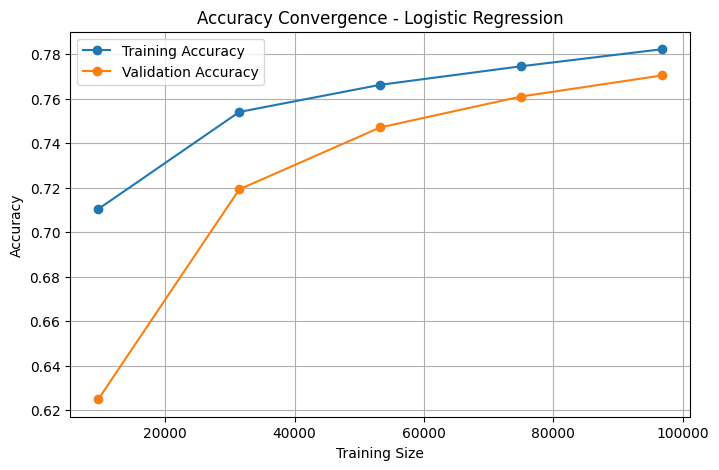

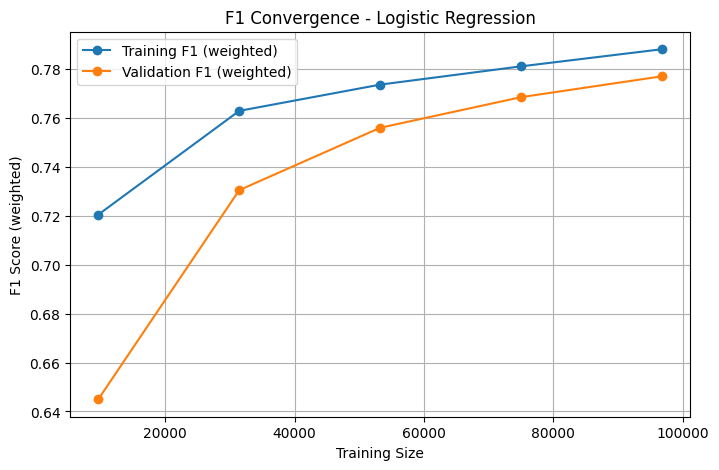

Generating convergence graphs for Naive Bayes...


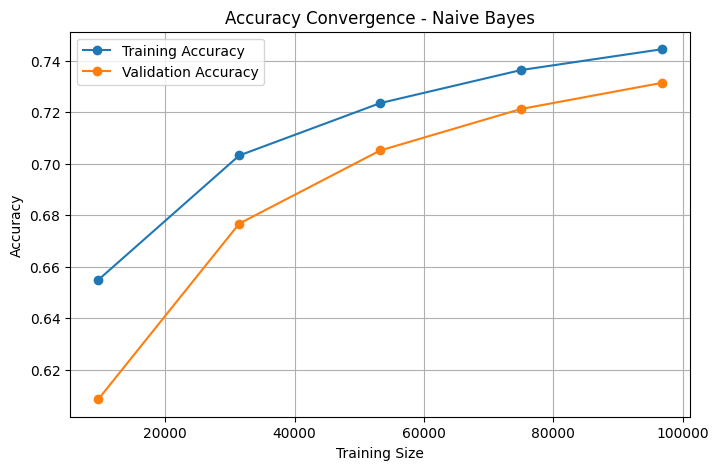

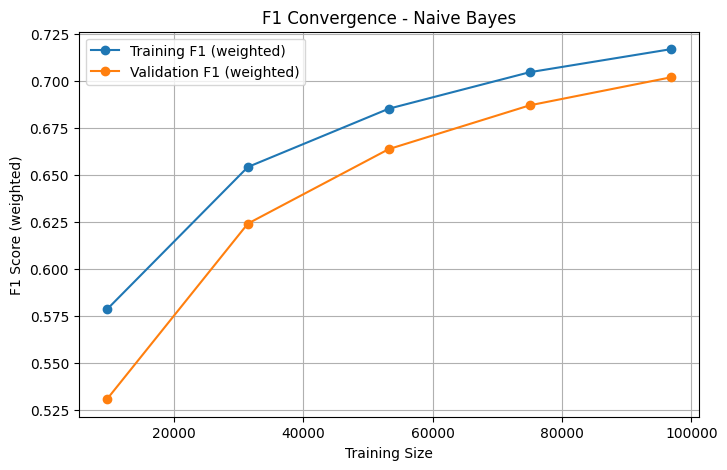

Generating convergence graphs for Random Forest...


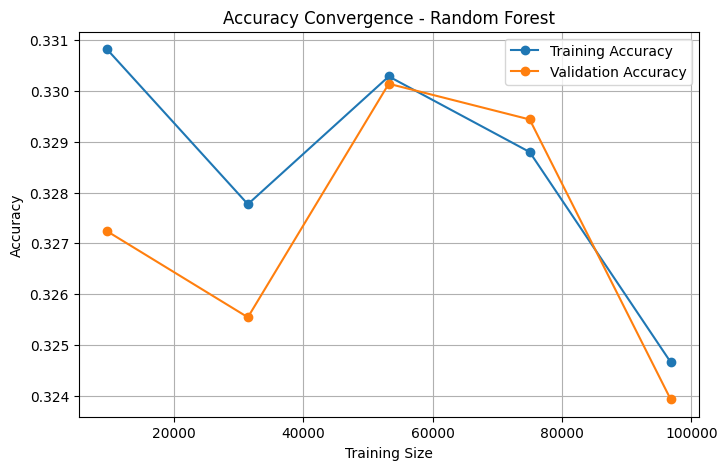

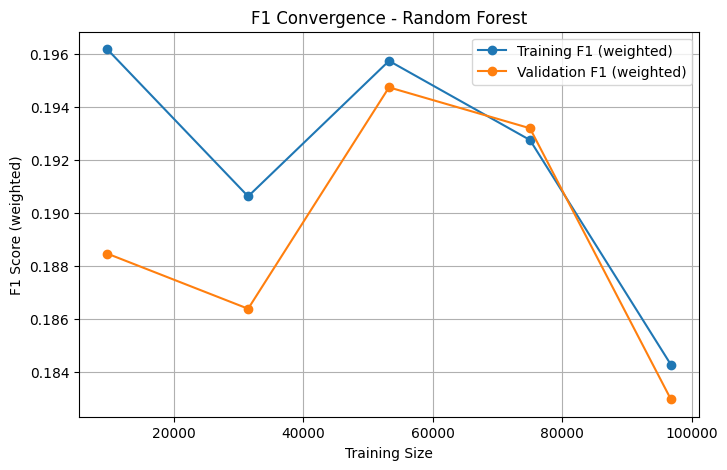

Generating convergence graphs for SVM...


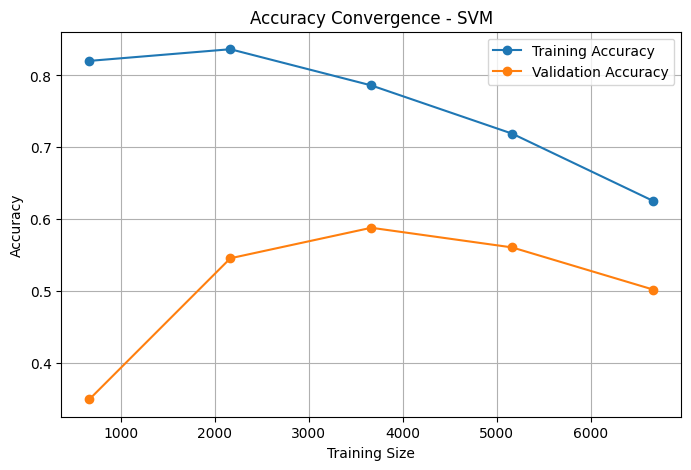

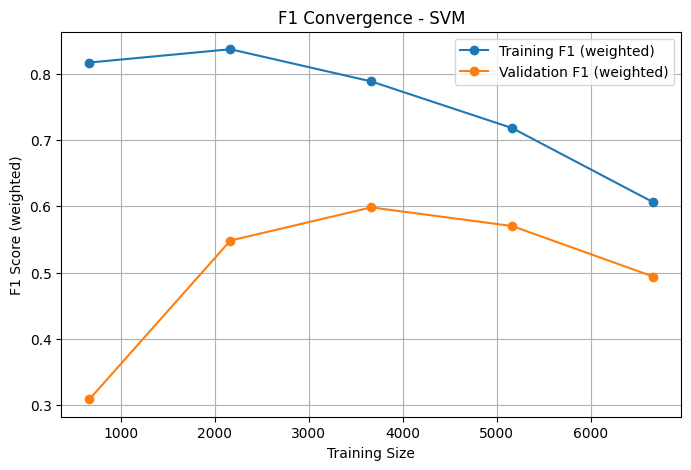

In [26]:
# Visualize training and validation convergence curves for ML models
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import make_scorer, f1_score

def plot_model_convergence(model, X, y, model_name):

    # Use fewer points to reduce computation time
    train_sizes = np.linspace(0.1, 1.0, 5)

    # Accuracy Convergence
    train_sizes_acc, train_scores_acc, val_scores_acc = learning_curve(
        model,
        X,
        y,
        cv=3,
        scoring='accuracy',
        train_sizes=train_sizes,
        n_jobs=-1
    )

    train_mean_acc = np.mean(train_scores_acc, axis=1)
    val_mean_acc = np.mean(val_scores_acc, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes_acc, train_mean_acc, marker='o', label="Training Accuracy")
    plt.plot(train_sizes_acc, val_mean_acc, marker='o', label="Validation Accuracy")
    plt.xlabel("Training Size")
    plt.ylabel("Accuracy")
    plt.title(f"Accuracy Convergence - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()

    # F1 Convergence
    f1_scorer = make_scorer(f1_score, average='weighted')

    train_sizes_f1, train_scores_f1, val_scores_f1 = learning_curve(
        model,
        X,
        y,
        cv=3,
        scoring=f1_scorer,
        train_sizes=train_sizes,
        n_jobs=-1
    )

    train_mean_f1 = np.mean(train_scores_f1, axis=1)
    val_mean_f1 = np.mean(val_scores_f1, axis=1)

    plt.figure(figsize=(8,5))
    plt.plot(train_sizes_f1, train_mean_f1, marker='o', label="Training F1 (weighted)")
    plt.plot(train_sizes_f1, val_mean_f1, marker='o', label="Validation F1 (weighted)")
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score (weighted)")
    plt.title(f"F1 Convergence - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


# Generate convergence graphs for each Machine Learning Model
# ---------------------------------------------------
for name, model in trained_models.items():

    print(f"Generating convergence graphs for {name}...")

    # Use subset for SVM to reduce computation time
    if name == "SVM":
        plot_model_convergence(model, X_train_svm, y_train_svm, name)
    else:
        plot_model_convergence(model, X_train_tfidf, y_train, name)

In [27]:
# Text Preprocessing
# Tokenization for deep learning models
MAX_WORDS = 20000 # This limits vocabulary to top 20000 most frequent words
MAX_LEN = 25      # Thus sets maximum sequence length to exactly 25 tokens
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(list(X_train) + list(X_val) + list(X_test))

seq_train = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN, padding='post', truncating='post')
seq_val = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN, padding='post', truncating='post')
seq_test = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN, padding='post', truncating='post')

num_classes = len(le.classes_)  # This counts number of unique interaction types
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_val_cat = to_categorical(y_val, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)
vocab_size = min(MAX_WORDS, len(tokenizer.word_index) + 1)
print('Vocab size:', vocab_size)

Vocab size: 1876


In [ ]:
# Training Deep Learning Models
# Convolutional Neural Network Model
cnn = Sequential([
    Embedding(vocab_size, 128, input_length=MAX_LEN),
    Conv1D(128, 5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])
cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)
]
print('Training CNN...')
history_cnn = cnn.fit(seq_train, y_train_cat, validation_data=(seq_val, y_val_cat), epochs=30, batch_size=256, callbacks=callbacks, verbose=1)
cnn_pred_proba = cnn.predict(seq_test)
cnn_pred = np.argmax(cnn_pred_proba, axis=1)
cnn_f1 = f1_score(y_test, cnn_pred, average='weighted', zero_division=0)

Training CNN...
Epoch 1/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 51s 87ms/step - accuracy: 0.6307 - loss: 1.2346 - val_accuracy: 0.7804 - val_loss: 0.6692 - learning_rate: 0.0010
Epoch 2/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 47s 84ms/step - accuracy: 0.8000 - loss: 0.6134 - val_accuracy: 0.8409 - val_loss: 0.4753 - learning_rate: 0.0010
Epoch 3/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 83s 85ms/step - accuracy: 0.8453 - loss: 0.4644 - val_accuracy: 0.8659 - val_loss: 0.3922 - learning_rate: 0.0010
Epoch 4/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 82s 86ms/step - accuracy: 0.8691 - loss: 0.3820 - val_accuracy: 0.8850 - val_loss: 0.3311 - learning_rate: 0.0010
Epoch 5/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 83s 87ms/step - accuracy: 0.8880 - loss: 0.3228 - val_accuracy: 0.8964 - val_loss: 0.2949 - learning_rate: 0.0010
Epoch 6/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 49s 87ms/step - accuracy: 0.9018 - loss: 0.2783 - val_accuracy: 0.9060 - val_loss: 0.2675 - learning_rate: 0.0010
Epoch 7/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 47s 82ms/step - accu

In [ ]:
# Bidirectional Long Short-Term Memory
bilstm = Sequential([
    Embedding(vocab_size, 128, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(128, activation='relu'),
    Dropout(0.4),
    Dense(num_classes, activation='softmax')
])
bilstm.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10)
]
print('Training BiLSTM...')
history_bilstm = bilstm.fit(seq_train, y_train_cat, validation_data=(seq_val, y_val_cat), epochs=30, batch_size=256, callbacks=callbacks, verbose=1)
bi_pred_proba = bilstm.predict(seq_test)
bi_pred = np.argmax(bi_pred_proba, axis=1)
bi_f1 = f1_score(y_test, bi_pred, average='weighted', zero_division=0)

Training BiLSTM...
Epoch 1/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 162s 267ms/step - accuracy: 0.5439 - loss: 1.4753 - val_accuracy: 0.6987 - val_loss: 0.9644 - learning_rate: 0.0010
Epoch 2/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 150s 263ms/step - accuracy: 0.7394 - loss: 0.8339 - val_accuracy: 0.7925 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 3/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 204s 267ms/step - accuracy: 0.8041 - loss: 0.6136 - val_accuracy: 0.8223 - val_loss: 0.5357 - learning_rate: 0.0010
Epoch 4/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 152s 267ms/step - accuracy: 0.8324 - loss: 0.5127 - val_accuracy: 0.8432 - val_loss: 0.4689 - learning_rate: 0.0010
Epoch 5/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 154s 271ms/step - accuracy: 0.8501 - loss: 0.4546 - val_accuracy: 0.8538 - val_loss: 0.4365 - learning_rate: 0.0010
Epoch 6/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 153s 269ms/step - accuracy: 0.8634 - loss: 0.4086 - val_accuracy: 0.8667 - val_loss: 0.3907 - learning_rate: 0.0010
Epoch 7/30
568/568 ━━━━━━━━━━━━━━━━━━━━ 148s 

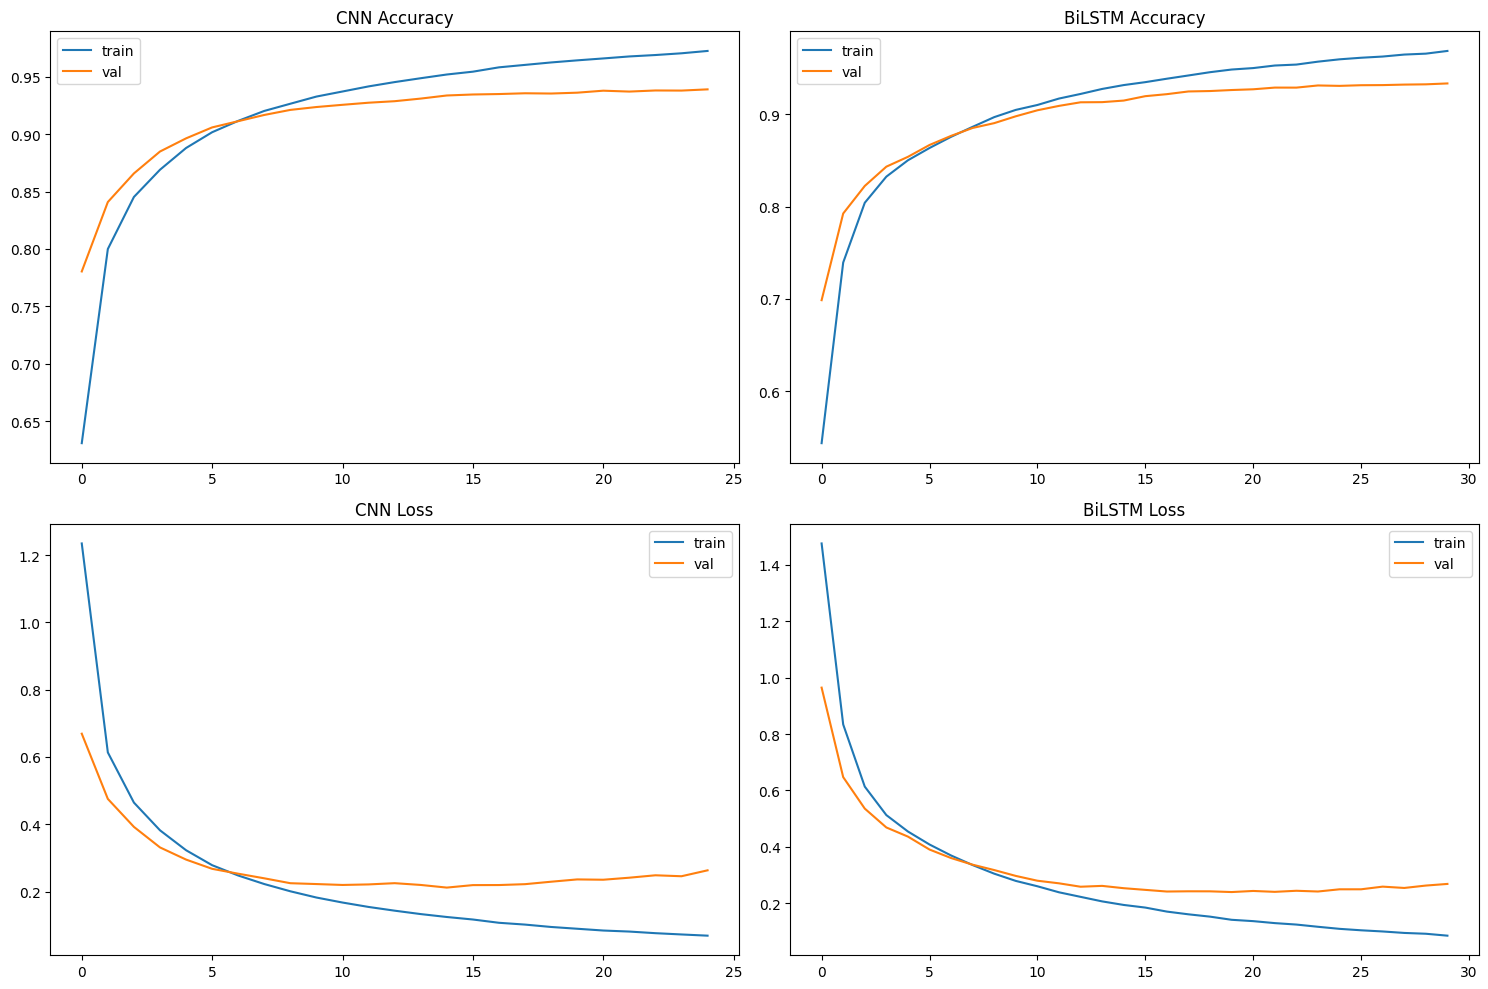

In [ ]:
# Accuracy and Loss Curves
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot CNN curves for training and validation
axes[0, 0].plot(history_cnn.history['accuracy'], label='train')
axes[0, 0].plot(history_cnn.history['val_accuracy'], label='val')
axes[0, 0].set_title('CNN Accuracy')
axes[0, 0].legend()

axes[1, 0].plot(history_cnn.history['loss'], label='train')
axes[1, 0].plot(history_cnn.history['val_loss'], label='val')
axes[1, 0].set_title('CNN Loss')
axes[1, 0].legend()

# Plot BiLSTM curves
axes[0, 1].plot(history_bilstm.history['accuracy'], label='train')
axes[0, 1].plot(history_bilstm.history['val_accuracy'], label='val')
axes[0, 1].set_title('BiLSTM Accuracy')
axes[0, 1].legend()

axes[1, 1].plot(history_bilstm.history['loss'], label='train')
axes[1, 1].plot(history_bilstm.history['val_loss'], label='val')
axes[1, 1].set_title('BiLSTM Loss')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

973/973 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step
973/973 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step


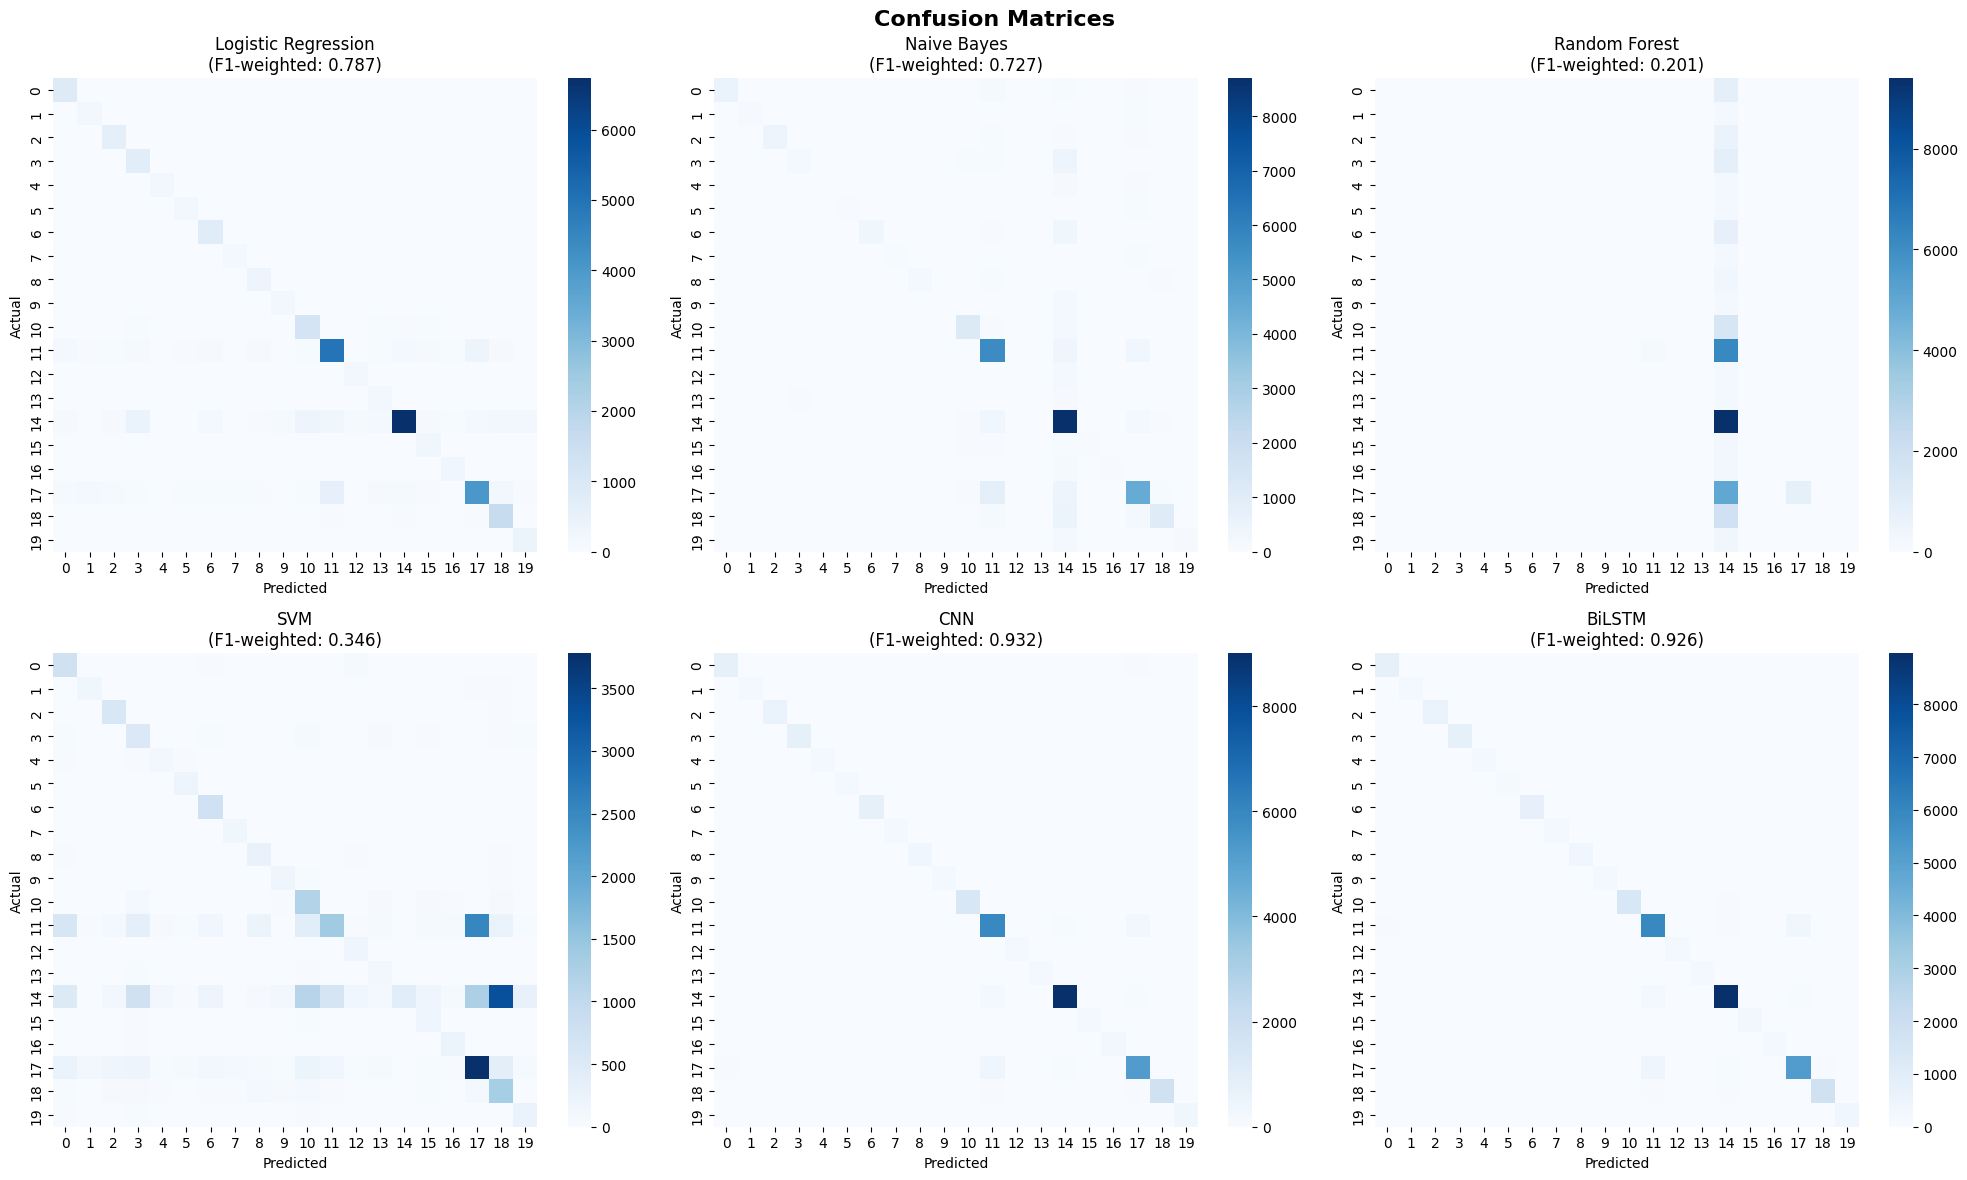


Diagonal = correct predictions
Off-diagonal = misclassifications


In [ ]:
# Confusion matrix to determine predictions, error analysis and performance visualisation
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Predictions for all models
model_predictions = {}

# Classical Machine learning models
for name in trained_models.keys():
    model_predictions[name] = trained_models[name].predict(X_test_tfidf)

# Deep learning models
cnn_pred = np.argmax(cnn.predict(seq_test), axis=1)
bilstm_pred = np.argmax(bilstm.predict(seq_test), axis=1)
model_predictions['CNN'] = cnn_pred
model_predictions['BiLSTM'] = bilstm_pred

# Create subplots
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(model_predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=False, cmap='Blues', fmt='d', ax=axes[idx])
    axes[idx].set_title(f'{name}\n(F1-weighted: {f1_score(y_test, y_pred, average="weighted", zero_division=0):.3f})')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nDiagonal = correct predictions")
print("Off-diagonal = misclassifications")

In [ ]:
# Determine the True Positives, True Negatives, False Positives, False Negatives of the models

model_predictions['CNN'] = np.argmax(cnn.predict(seq_test), axis=1)
model_predictions['BiLSTM'] = np.argmax(bilstm.predict(seq_test), axis=1)

results_table = []

for name, y_pred in model_predictions.items():
    cm = confusion_matrix(y_test, y_pred)

    # For multiclass: sum diagonals (TP), sum off-diagonals appropriately
    TP = np.trace(cm)  # Sum of diagonal = all correct predictions
    total = cm.sum()
    TN = 0  # True negatives per class summed (complex for multiclass)
    FP = cm.sum(axis=0) - np.diag(cm)  # Predicted positive, actually negative
    FN = cm.sum(axis=1) - np.diag(cm)  # Predicted negative, actually positive

    # Aggregate multiclass metrics
    total_TP = TP
    total_FP = FP.sum()
    total_FN = FN.sum()
    total_TN = total - total_TP - total_FP - total_FN

    results_table.append({
        'Model': name,
        'TP': total_TP,
        'TN': total_TN,
        'FP': total_FP,
        'FN': total_FN,
    })

# Confusion Matrix Table
tp_table = pd.DataFrame(results_table)
print("\n" + "="*50)
print("Confusion Matrix Table for TP, TN, FP, FN")
print("="*50)
print(tp_table.round(1).to_string(index=False, float_format='%.1f'))

973/973 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step

Confusion Matrix Table for TP, TN, FP, FN
              Model    TP     TN    FP    FN
Logistic Regression 24307  -6805  6805  6805
        Naive Bayes 23340  -7772  7772  7772
      Random Forest 10396 -20716 20716 20716
                SVM 12784 -18328 18328 18328
                CNN 28997  -2115  2115  2115
             BiLSTM 28790  -2322  2322  2322


In [ ]:
# To show the prediction samples of what the model is supposed to produce in order to easily understand drug pairs and their interactions
# It shows the combination of two drugs and its interaction type because the models does not aim to just detect drug interaction but to
# also help healthcare professsionals know the exact effect of the interaction of the drug pairs
def predict_interaction(drug1, drug2, model_name='BiLSTM'):
    """Predict: "drug1 + drug2 causes interaction_type" """
    sentence = f"{drug1} + {drug2}"

    if model_name in trained_models:
        pred_id = trained_models[model_name].predict(vectorizer.transform([sentence]))[0]
    elif model_name == 'CNN':
        seq = pad_sequences(tokenizer.texts_to_sequences([sentence]), maxlen=MAX_LEN, padding='post')
        pred_id = np.argmax(cnn.predict(seq, verbose=0), axis=1)[0]
    else:
        seq = pad_sequences(tokenizer.texts_to_sequences([sentence]), maxlen=MAX_LEN, padding='post')
        pred_id = np.argmax(bilstm.predict(seq, verbose=0), axis=1)[0]

    return f"{drug1} + {drug2} causes {le.inverse_transform([pred_id])[0]}"

# Test the models
print("=== PREDICTION EXAMPLES ===")
print(predict_interaction('Bivalirudin', 'Alfuzosin', 'BiLSTM'))
print(predict_interaction('Aspirin', 'Ibuprofen', 'Logistic Regression'))
print(predict_interaction('Warfarin', 'Aspirin', 'CNN'))

=== PREDICTION EXAMPLES ===
Bivalirudin + Alfuzosin causes serum concentration
Aspirin + Ibuprofen causes risk or severity of adverse effects
Warfarin + Aspirin causes anticoagulant activities


973/973 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
973/973 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step


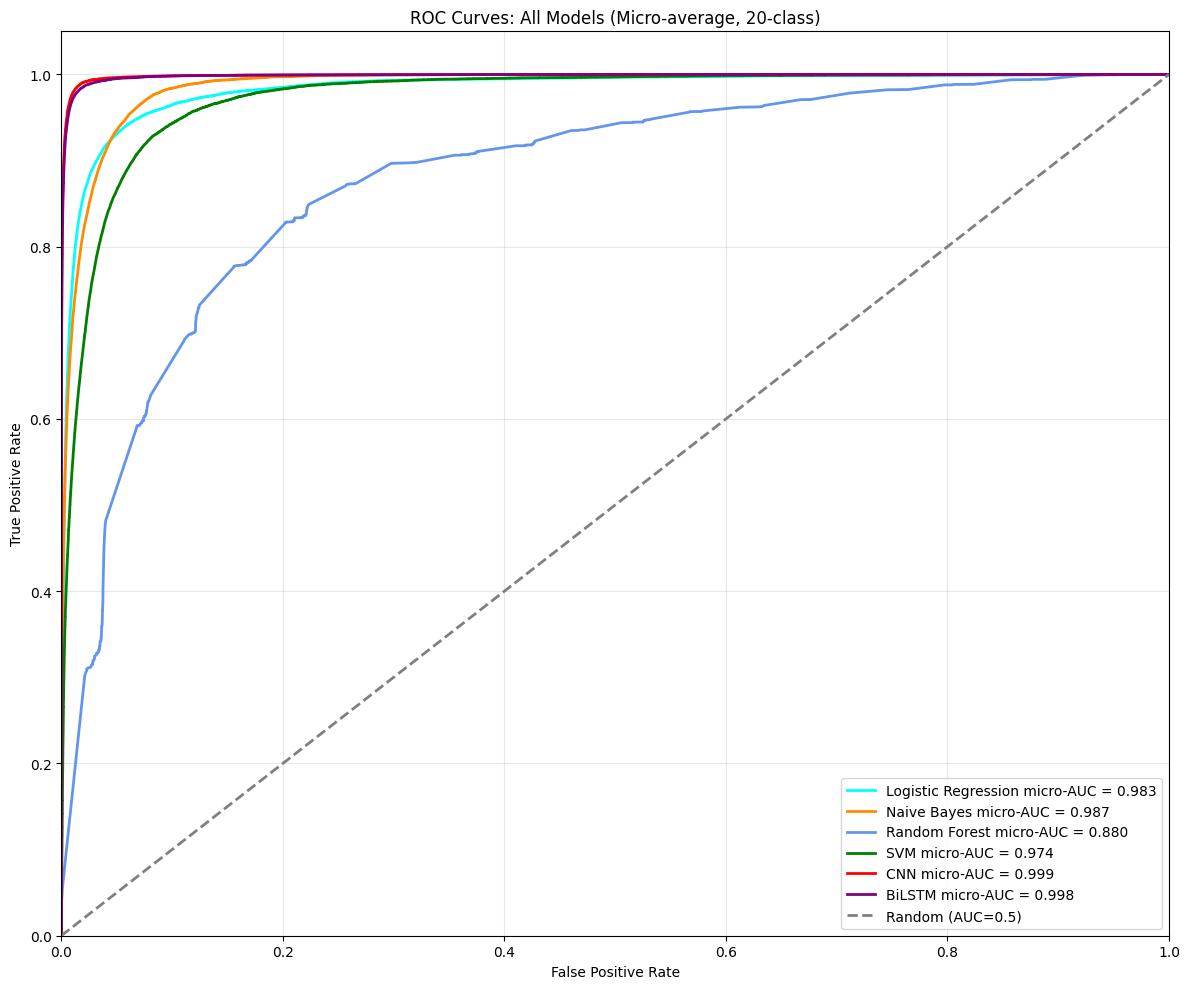


MODEL ROC-AUC (Micro-average):
                 Model   ROC-AUC
4                  CNN  0.998534
5               BiLSTM  0.998273
1          Naive Bayes  0.987318
0  Logistic Regression  0.983493
3                  SVM  0.973899
2        Random Forest  0.879942


In [ ]:
# ROC Curves and AUC
from itertools import cycle

# Get probability predictions for all the models
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))
n_classes = y_test_bin.shape[1]

# Store ROC data
roc_data = {}

# Machine Learning Models
for name in trained_models.keys():
    if hasattr(trained_models[name], 'predict_proba'):
        y_score = trained_models[name].predict_proba(X_test_tfidf)
        roc_data[name] = y_score
    else:
        print(f"{name} skipped (no probabilities)")

# Deep learning Models
roc_data['CNN'] = cnn.predict(seq_test)
roc_data['BiLSTM'] = bilstm.predict(seq_test)

# Plot ALL ROC curves
plt.figure(figsize=(12, 10))
colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'green', 'red', 'purple'])
lw = 2

for model_name, y_score in roc_data.items():
    # Micro-average ROC
    fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    plt.plot(fpr_micro, tpr_micro, color=next(colors), lw=lw,
             label=f'{model_name} micro-AUC = {roc_auc_micro:.3f}')

plt.plot([0, 1], [0, 1], color='gray', lw=lw, linestyle='--', label='Random (AUC=0.5)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: All Models (Micro-average, 20-class)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

# Print AUC table
print("\nMODEL ROC-AUC (Micro-average):")
auc_scores = {name: auc(roc_curve(y_test_bin.ravel(), y_score.ravel())[0],
                       roc_curve(y_test_bin.ravel(), y_score.ravel())[1])
              for name, y_score in roc_data.items()}
auc_df = pd.DataFrame(list(auc_scores.items()), columns=['Model', 'ROC-AUC'])
print(auc_df.sort_values('ROC-AUC', ascending=False))

In [ ]:
# COMPARATIVE MODEL PERFORMANCE
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
)
from sklearn.preprocessing import label_binarize

# Compute the model predictions
model_predictions = {}
model_probabilities = {}

# Machine learning predictions and probabilities
for name, model in trained_models.items():
    model_predictions[name] = model.predict(X_test_tfidf)
    if hasattr(model, 'predict_proba'):
        model_probabilities[name] = model.predict_proba(X_test_tfidf)
    else:
        model_probabilities[name] = None

# Deep learning predictions and probabilities
model_predictions['CNN'] = np.argmax(cnn.predict(seq_test), axis=1)
model_predictions['BiLSTM'] = np.argmax(bilstm.predict(seq_test), axis=1)
model_probabilities['CNN'] = cnn.predict(seq_test)
model_probabilities['BiLSTM'] = bilstm.predict(seq_test)

# Compute the key metrics
final_results = []
y_test_bin = label_binarize(y_test, classes=np.arange(len(le.classes_)))

for model_name in model_predictions.keys():
    y_pred = model_predictions[model_name]

    accuracy = accuracy_score(y_test, y_pred)
    precision_w = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall_w = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_w = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    f1_m = f1_score(y_test, y_pred, average='macro', zero_division=0)

    # ROC-AUC
    if model_probabilities[model_name] is not None:
        try:
            roc_auc = roc_auc_score(y_test_bin, model_probabilities[model_name], multi_class='ovr', average='macro')
        except:
            roc_auc = np.nan
    else:
        roc_auc = np.nan

    final_results.append({
        'Model': model_name,
        'Accuracy': f'{accuracy:.3f}',
        'Precision(W)': f'{precision_w:.3f}',
        'Recall(W)': f'{recall_w:.3f}',
        'F1_Weighted': f'{f1_w:.3f}',
        'F1_Macro': f'{f1_m:.3f}',
        'ROC-AUC': f'{roc_auc:.3f}' if not np.isnan(roc_auc) else 'N/A'
    })

# COMPARATIVE PERFORMANCE TABLE
final_table = pd.DataFrame(final_results)
final_table = final_table.sort_values('F1_Weighted', ascending=False).reset_index(drop=True)

print("\n" + "═"*90)
print("--------------------COMPARATIVE PERFORMANCE TABLE------------------")
print("═"*90)
print(final_table.to_string(index=False))

# Save for thesis (perfect formatting)
final_table_styled = final_table.style.format({
    'Accuracy': '{:.3f}',
    'Precision(W)': '{:.3f}',
    'Recall(W)': '{:.3f}',
    'F1_Weighted': '{:.3f}',
    'F1_Macro': '{:.3f}',
    'ROC-AUC': '{:.3f}'
}).background_gradient(subset=['F1_Weighted'], cmap='viridis')

973/973 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
973/973 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step
973/973 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step
973/973 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step

══════════════════════════════════════════════════════════════════════════════════════════
--------------------COMPARATIVE PERFORMANCE TABLE------------------
══════════════════════════════════════════════════════════════════════════════════════════
              Model Accuracy Precision(W) Recall(W) F1_Weighted F1_Macro ROC-AUC
                CNN    0.932        0.933     0.932       0.932    0.940   0.998
             BiLSTM    0.925        0.926     0.925       0.926    0.932   0.997
Logistic Regression    0.781        0.824     0.781       0.787    0.748   0.988
        Naive Bayes    0.750        0.761     0.750       0.727    0.507   0.988
                SVM    0.411        0.624     0.411       0.346    0.495   0.967
      Random Forest    0.334        0.516     0.334       0.201    0.039   0.751
